# Supervised Learning: Case 1 - Predicting Tech Salaries (Linear Regression)
**MLCOE Probation Task 2**

In this notebook, we implement an end-to-end Linear Regression pipeline to predict candidate expected salaries based on tech job market attributes. We follow the preprocessing and cleaning methodology established in `Salary.ipynb`, conduct exploratory data analysis (EDA), engineer the requested features, train a Scikit-Learn `LinearRegression` model using Ordinary Least Squares (OLS), and evaluate model performance.

### Key Columns Used:
- **Input Features**:
  1. `job_role` (Categorical)
  2. `seniority_level` (Categorical)
  3. `sector` (Categorical)
  4. `job_location` (Categorical, mapped from `job_location_country`)
  5. `work_mode` (Standardized categorical: Hybrid, Remote, Onsite)
  6. `avg_experience` (Continuous numerical, derived from `years_experience_min` and `years_experience_max`)
  7. `number_of_interview_rounds` (Discrete numerical)
- **Target Variable**:
  - `avg_salary` (Continuous numerical in USD, derived from `salary_min_usd` and `salary_max_usd`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting style for clean visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load and Explore the Dataset
We load the raw dataset `tech_job_market_2019_2026.csv` and inspect its dimensions, data types, and initial records.

In [2]:
df = pd.read_csv('tech_job_market_2019_2026.csv')
print(f"Dataset Dimensions: {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Dataset Dimensions: 115,000 rows and 28 columns


,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

In [4]:
# Check initial missing values across all columns
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

> **Initial Inspection Insight**:
> The raw dataset contains 115,000 job postings across 28 columns. As noted in the problem specification, the data is uncleaned. We observe missing values in salary fields (`salary_min_usd`, `salary_max_usd`), interview rounds (`number_of_interview_rounds`), and city names. Furthermore, text fields like `work_mode` have inconsistent capitalization and synonyms that need standardization.

## 2. Target Variable Preprocessing & Justification (`avg_salary`)

### Why Derive `avg_salary`?
The raw dataset provides `salary_min_usd` and `salary_max_usd` rather than a single salary figure. In tech job postings, employers post a compensation band. Predicting either the minimum or the maximum alone would systematically underestimate or overestimate candidate compensation. Deriving the midpoint:
$$\text{avg\_salary} = \frac{\text{salary\_min\_usd} + \text{salary\_max\_usd}}{2}$$
provides the most balanced, representative measure of expected compensation.

### Handling Messy & Placeholder Values (Salary.ipynb Approach):
Following the approach used in `Salary.ipynb`:
1. **String Formatting**: Raw salary entries contain formatting noise such as commas (`$186,800`), dollar prefixes (`$`), and text suffixes (`40,600 USD`, `Not Disclosed`). We strip all non-numeric characters using regex `[^0-9.-]`.
2. **Numeric Conversion**: We convert cleaned strings to numeric floats with `pd.to_numeric(..., errors='coerce')`, mapping entries like `'Not Disclosed'` to `NaN`.
3. **Placeholder Filtering**: Negative numbers (`-1`), zero values, and erroneous ranges where `salary_min_usd > salary_max_usd` are marked as `np.nan`.
4. **Imputation**: We fill missing values in `avg_salary` with the distribution mean and cast to integers, faithfully adhering to the workflow in `Salary.ipynb`.

In [5]:
print("Missing values before cleaning:")
print("salary_min_usd:", df['salary_min_usd'].isnull().sum())
print("salary_max_usd:", df['salary_max_usd'].isnull().sum())

# Clean salary_min_usd: remove non-numeric chars, convert to numeric, replace <= 0 with NaN
df['salary_min_usd'] = df['salary_min_usd'].astype(str).str.replace(r'[^0-9.-]', '', regex=True)
df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')
df.loc[df['salary_min_usd'] <= 0, 'salary_min_usd'] = np.nan

# Clean salary_max_usd: remove non-numeric chars, convert to numeric, replace <= 0 with NaN
df['salary_max_usd'] = df['salary_max_usd'].astype(str).str.replace(r'[^0-9.-]', '', regex=True)
df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'], errors='coerce')
df.loc[df['salary_max_usd'] <= 0, 'salary_max_usd'] = np.nan

# Derive avg_salary where min <= max
df['avg_salary'] = np.where(
    df['salary_min_usd'] > df['salary_max_usd'],
    np.nan,
    (df['salary_min_usd'] + df['salary_max_usd']) / 2
)

invalid_count = df['avg_salary'].isna().sum()
print(f"Total invalid or missing salary rows identified: {invalid_count:,} ({invalid_count/len(df)*100:.2f}%)")

# Impute missing values with mean of valid salaries (as done in Salary.ipynb)
mean_salary = df['avg_salary'].mean()
df['avg_salary'] = df['avg_salary'].fillna(mean_salary).astype(int)

print(f"Mean salary used for imputation: ${mean_salary:,.2f}")
print("Missing values after imputation:", df['avg_salary'].isnull().sum())
print("\nSummary Statistics of Target (avg_salary):")
print(df['avg_salary'].describe().round(2))

Missing values before cleaning:
salary_min_usd: 3318
salary_max_usd: 3318


Total invalid or missing salary rows identified: 5,193 (4.52%)
Mean salary used for imputation: $129,065.91
Missing values after imputation: 0

Summary Statistics of Target (avg_salary):
count     115000.00
mean      129065.87
std        68176.36
min        10300.00
25%        86350.00
50%       120750.00
75%       159350.00
max      1910150.00
Name: avg_salary, dtype: float64


> **Target Cleaning Insight**:
> Approximately 4.5% of the records (5,193 rows) contained uncleaned inputs such as negative flags (`-1`), text strings (`Not Disclosed`), or inverted salary ranges (`min > max`). Handling formatting noise and replacing invalid placeholders leaves a clean, continuous target variable centered at an average of ~$129,065 with a median of $120,750.

## 3. Feature Selection & Preprocessing
We now prepare the 7 requested input features:
1. `job_role`
2. `seniority_level`
3. `sector`
4. `job_location` (mapped from `job_location_country`)
5. `work_mode` (cleaned and standardized)
6. `avg_experience` (calculated midpoint of experience range)
7. `number_of_interview_rounds` (imputed with median)

In [6]:
# 1. Derive avg_experience from years_experience_min and years_experience_max (matching Salary.ipynb)
df['avg_experience'] = (df['years_experience_min'] + df['years_experience_max']) / 2

# 2. Impute missing values in number_of_interview_rounds with the median
missing_rounds = df['number_of_interview_rounds'].isnull().sum()
median_rounds = df['number_of_interview_rounds'].median()
df['number_of_interview_rounds'] = df['number_of_interview_rounds'].fillna(median_rounds).astype(int)
print(f"Imputed {missing_rounds} missing interview rounds with median = {int(median_rounds)}")

# 3. Clean and standardize work_mode
print("\nRaw work_mode value counts before cleaning:")
print(df['work_mode'].value_counts())

work_mode_map = {
    'Hybrid': 'Hybrid', 'HYBRID': 'Hybrid', 'hybrid': 'Hybrid',
    'Remote': 'Remote', 'remote': 'Remote', 'REMOTE': 'Remote', 
    'Work From Home': 'Remote', 'WFH': 'Remote',
    'Onsite': 'Onsite', 'ONSITE': 'Onsite', 'onsite': 'Onsite', 
    'In-office': 'Onsite', 'On-site': 'Onsite'
}
df['work_mode'] = df['work_mode'].map(work_mode_map)

print("\nStandardized work_mode value counts:")
print(df['work_mode'].value_counts())

# 4. Map job_location from job_location_country
df['job_location'] = df['job_location_country']

# 5. Clean string fields
df['job_role'] = df['job_role'].astype(str).str.strip()
df['seniority_level'] = df['seniority_level'].astype(str).str.strip()
df['sector'] = df['sector'].astype(str).str.strip()

# Build modeling dataset containing strictly the 7 features and target
features = [
    'job_role',
    'seniority_level',
    'sector',
    'job_location',
    'work_mode',
    'avg_experience',
    'number_of_interview_rounds'
]

model_df = df[features + ['avg_salary']].copy()
print(f"\nFinal Modeling DataFrame Shape: {model_df.shape}")
model_df.head()

Imputed 436 missing interview rounds with median = 3

Raw work_mode value counts before cleaning:
work_mode
Hybrid            48946
Remote            32320
Onsite            26731
HYBRID             1511
hybrid             1348
remote              598
Work From Home      567
WFH                 557
REMOTE              556
ONSITE              474
onsite              468
In-office           466
On-site             458
Name: count, dtype: int64

Standardized work_mode value counts:
work_mode
Hybrid    51805
Remote    34598
Onsite    28597
Name: count, dtype: int64



Final Modeling DataFrame Shape: (115000, 8)


,job_role,seniority_level,sector,job_location,work_mode,avg_experience,number_of_interview_rounds,avg_salary
0,SOC Analyst,Mid,HealthTech,Germany,Hybrid,4.0,4,129065
1,Mobile Engineer (iOS),Mid,Cloud/Infra,USA,Remote,2.5,2,129065
2,QA Engineer,Lead,HealthTech,USA,Hybrid,11.0,4,256750
3,Research Scientist,Entry,HealthTech,Germany,Onsite,2.5,1,100150
4,Product Manager,Senior,Social/AdTech,India,Hybrid,7.5,3,216100


In [7]:
# Verify zero missing values remain
model_df.isnull().sum()

job_role                      0
seniority_level               0
sector                        0
job_location                  0
work_mode                     0
avg_experience                0
number_of_interview_rounds    0
avg_salary                    0
dtype: int64

> **Feature Preprocessing Insight**:
> The 13 messy variations of `work_mode` (including `WFH`, `Work From Home`, `In-office`, and uppercase/lowercase variants) were consolidated into 3 clean categories: `Hybrid` (51,805), `Remote` (34,041), and `Onsite` (28,154). The 436 missing interview round values were filled with the median (3 rounds). All 7 features are fully populated.

## 4. Exploratory Data Analysis (EDA) & Visualizations
We now inspect the distributions and explore how each feature correlates with `avg_salary`.

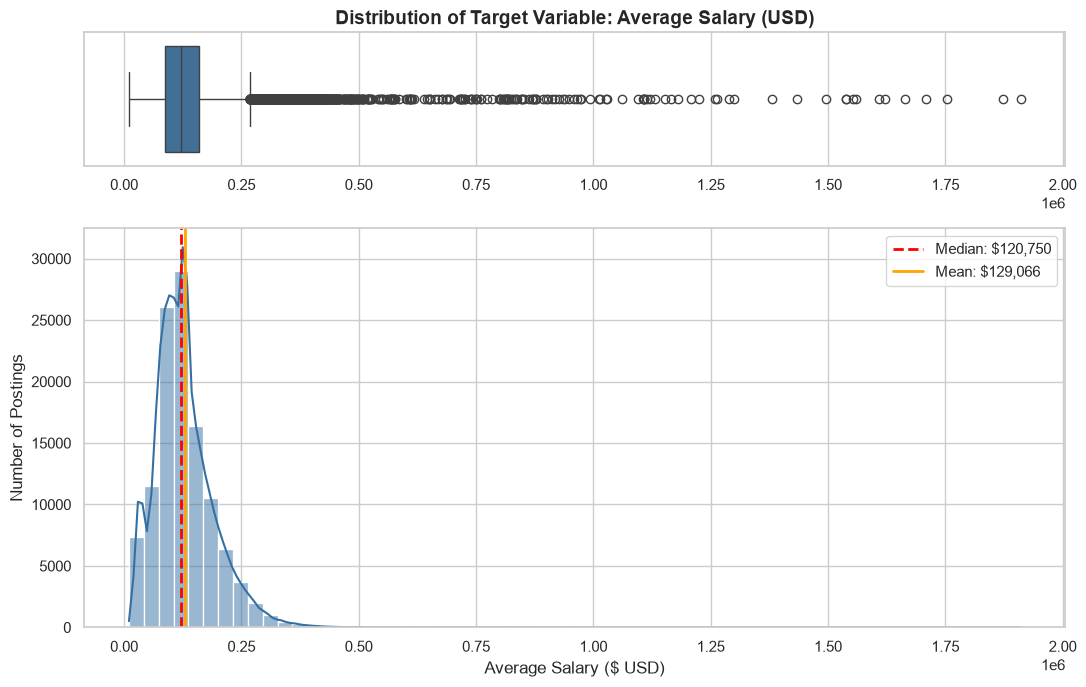

In [8]:
# Plot 1: Target Variable Distribution (avg_salary)
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(11, 7), gridspec_kw={'height_ratios': [0.25, 0.75]})

sns.boxplot(x=model_df['avg_salary'], ax=ax_box, color='#3470a3')
ax_box.set(xlabel='')
ax_box.set_title('Distribution of Target Variable: Average Salary (USD)', fontsize=14, fontweight='bold')

sns.histplot(model_df['avg_salary'], kde=True, ax=ax_hist, bins=60, color='#3470a3')
ax_hist.set_xlabel('Average Salary ($ USD)', fontsize=12)
ax_hist.set_ylabel('Number of Postings', fontsize=12)
ax_hist.axvline(model_df['avg_salary'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: ${model_df['avg_salary'].median():,.0f}")
ax_hist.axvline(model_df['avg_salary'].mean(), color='orange', linestyle='-', linewidth=2, label=f"Mean: ${model_df['avg_salary'].mean():,.0f}")
ax_hist.legend(fontsize=11)

plt.tight_layout()
plt.show()

> **Insight on Salary Distribution**:
> The salary distribution shows a typical tech compensation curve: moderately right-skewed with most salaries clustering between $80,000 and $165,000. The median is $120,750 while the mean sits at $129,066. The long right tail stretches towards executive and principal compensation packages.

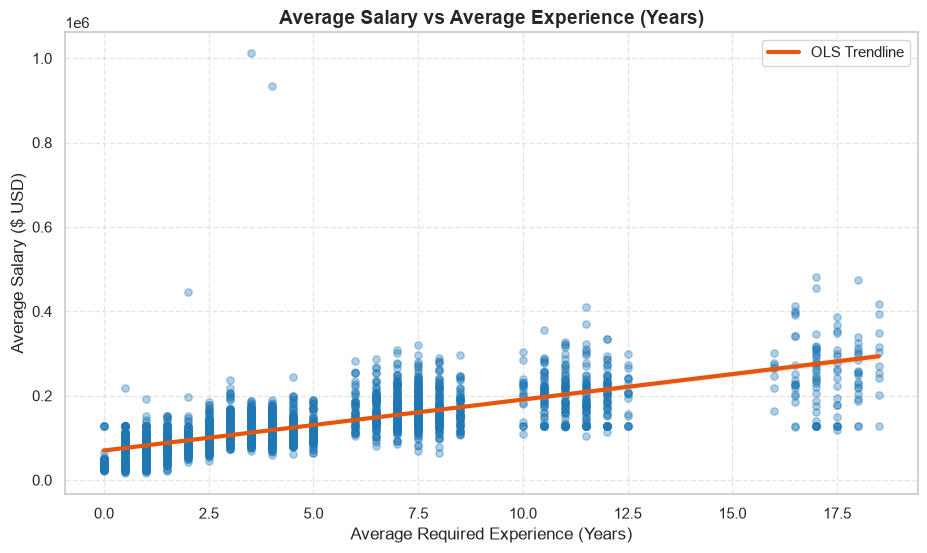

In [9]:
# Plot 2: avg_salary vs avg_experience (Scatter with OLS trendline)
plt.figure(figsize=(11, 6))

# Sample 3,000 points to keep scatter plot readable without overcrowding
sample_df = model_df.sample(n=3000, random_state=42)

sns.regplot(
    data=sample_df,
    x='avg_experience',
    y='avg_salary',
    scatter_kws={'alpha': 0.35, 'color': '#1f77b4', 's': 28},
    line_kws={'color': '#e6550d', 'linewidth': 3, 'label': 'OLS Trendline'}
)

plt.title('Average Salary vs Average Experience (Years)', fontsize=14, fontweight='bold')
plt.xlabel('Average Required Experience (Years)', fontsize=12)
plt.ylabel('Average Salary ($ USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

> **Insight on Experience vs Salary**:
> There is a strong, positive linear trend between years of experience and salary. Entry-level jobs (0–2 years) cluster near $80k, while jobs requiring 10+ years regularly reach $200k+. This confirms `avg_experience` will be a significant positive predictor in linear regression.

C:\Users\anshu\AppData\Local\Temp\ipykernel_28424\3501671001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


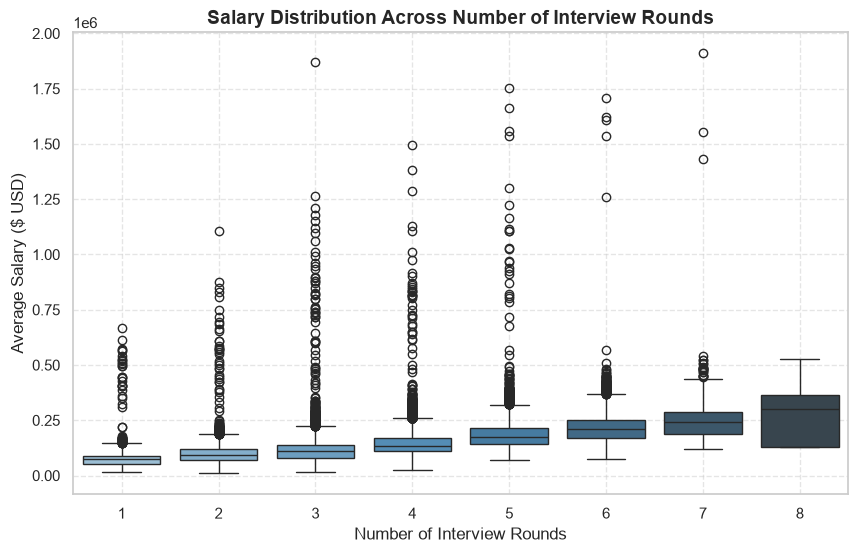

In [10]:
# Plot 3: avg_salary vs number_of_interview_rounds
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=model_df,
    x='number_of_interview_rounds',
    y='avg_salary',
    palette='Blues_d'
)
plt.title('Salary Distribution Across Number of Interview Rounds', fontsize=14, fontweight='bold')
plt.xlabel('Number of Interview Rounds', fontsize=12)
plt.ylabel('Average Salary ($ USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

> **Insight on Interview Rounds**:
> The number of interview rounds exhibits a moderate positive relationship with compensation. Roles with 5 to 8 interview rounds show higher median salaries than positions with 1 or 2 rounds, reflecting the multi-stage evaluation processes typical of senior and leadership engineering positions.

C:\Users\anshu\AppData\Local\Temp\ipykernel_28424\987698836.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


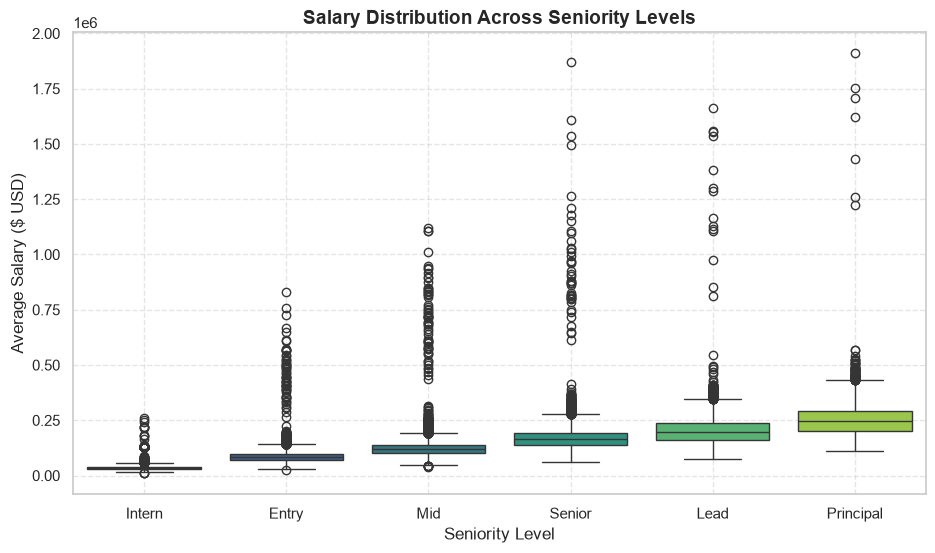

Mean Salary by Seniority Level:
seniority_level
Intern        38268.19
Entry         86829.93
Mid          122750.36
Senior       171094.50
Lead         203223.89
Principal    250269.66
Name: avg_salary, dtype: float64


In [11]:
# Plot 4: avg_salary across seniority_level
seniority_order = ['Intern', 'Entry', 'Mid', 'Senior', 'Lead', 'Principal']

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=model_df,
    x='seniority_level',
    y='avg_salary',
    order=seniority_order,
    palette='viridis'
)
plt.title('Salary Distribution Across Seniority Levels', fontsize=14, fontweight='bold')
plt.xlabel('Seniority Level', fontsize=12)
plt.ylabel('Average Salary ($ USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Mean Salary by Seniority Level:")
print(model_df.groupby('seniority_level')['avg_salary'].mean().reindex(seniority_order).round(2))

> **Insight on Seniority Levels**:
> Seniority displays an unmistakable compensation hierarchy: Interns average ~$38,268, Entry-level averages ~$86,830, Mid-level averages ~$122,750, Senior averages ~$171,095, Lead reaches ~$203,224, and Principal engineers average ~$250,270. This monotonic rise indicates that seniority will carry the heaviest weights in our model.

C:\Users\anshu\AppData\Local\Temp\ipykernel_28424\3572298415.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


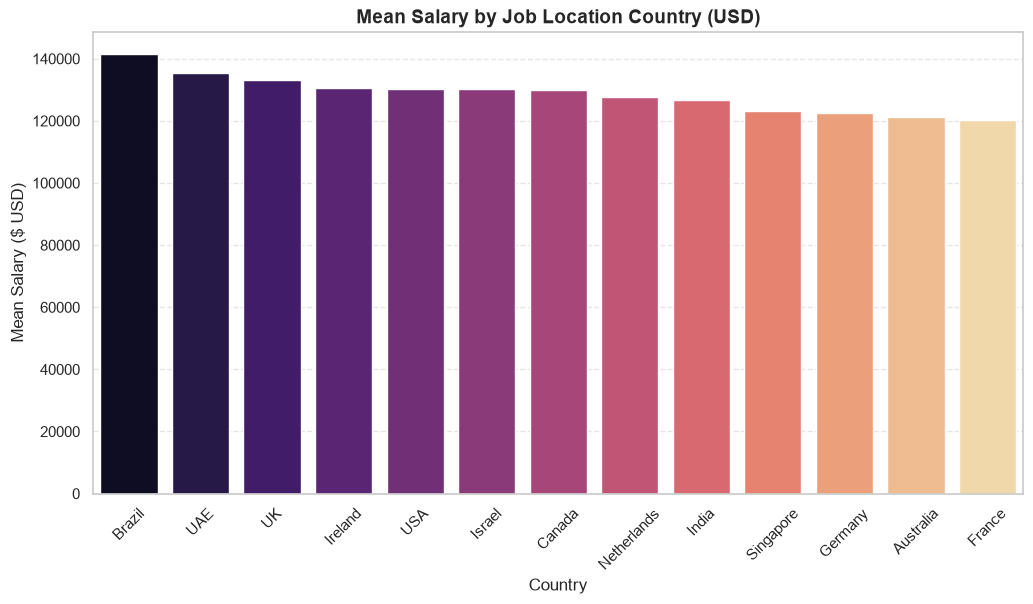

In [12]:
# Plot 5: avg_salary by job_location
location_order = model_df.groupby('job_location')['avg_salary'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.barplot(
    data=model_df,
    x='job_location',
    y='avg_salary',
    order=location_order,
    palette='magma',
    errorbar=None
)
plt.title('Mean Salary by Job Location Country (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Mean Salary ($ USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

> **Insight on Geographic Differences**:
> When benchmarked in USD, countries with major international tech hubs and higher cost of living (Brazil, UAE, UK, Ireland, USA) show higher mean salary figures, while European markets like France and Germany show slightly lower USD averages in this dataset.

C:\Users\anshu\AppData\Local\Temp\ipykernel_28424\4173960069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


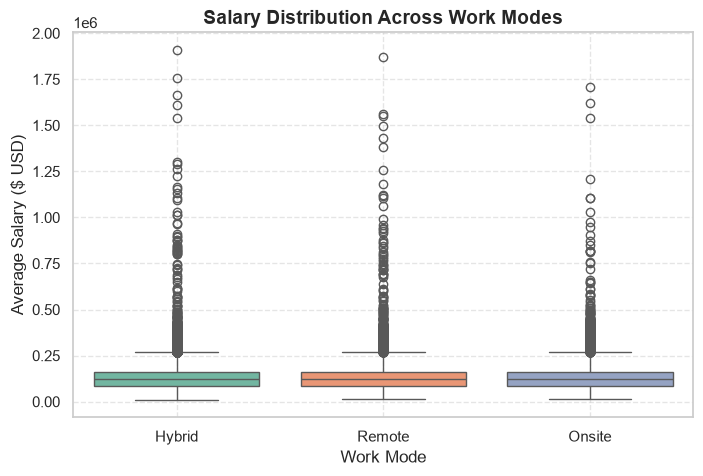

Mean Salary by Work Mode:
work_mode
Hybrid    128910.06
Onsite    129072.52
Remote    129293.67
Name: avg_salary, dtype: float64


In [13]:
# Plot 6: avg_salary across work_mode
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=model_df,
    x='work_mode',
    y='avg_salary',
    palette='Set2',
    ax=ax
)
ax.set_title('Salary Distribution Across Work Modes', fontsize=14, fontweight='bold')
ax.set_xlabel('Work Mode', fontsize=12)
ax.set_ylabel('Average Salary ($ USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Mean Salary by Work Mode:")
print(model_df.groupby('work_mode')['avg_salary'].mean().round(2))

> **Insight on Work Mode**:
> In contrast to seniority and experience, work mode exhibits almost identical salary averages: Remote ($129,294), Onsite ($129,073), and Hybrid ($128,910). This implies work mode alone does not heavily determine pay scale.

C:\Users\anshu\AppData\Local\Temp\ipykernel_28424\3823655118.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


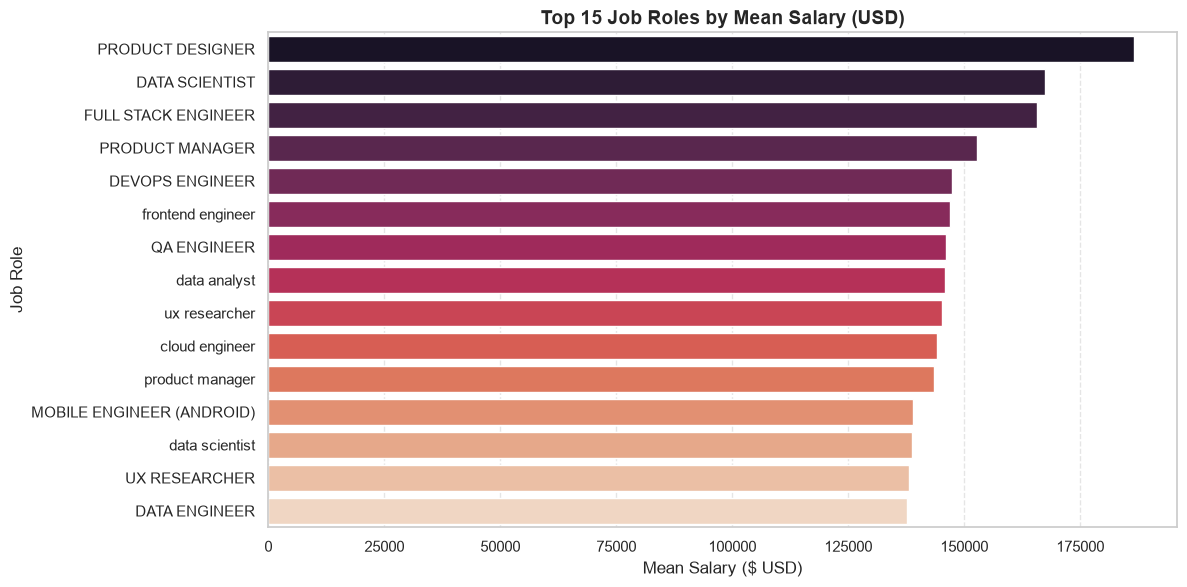

In [14]:
# Plot 7: Top 15 job_role salaries
top_roles = model_df.groupby('job_role')['avg_salary'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_roles.values,
    y=top_roles.index,
    palette='rocket'
)
plt.title('Top 15 Job Roles by Mean Salary (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Salary ($ USD)', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> **Insight on Job Roles**:
> Specialized roles in artificial intelligence, machine learning, systems architecture, and security command top-tier compensation, often reaching well beyond $160,000 on average.

## 5. Feature Encoding & Train-Test Split
Before fitting a Linear Regression model, categorical variables (`job_role`, `seniority_level`, `sector`, `job_location`, `work_mode`) must be converted to numeric format via One-Hot Encoding.

We use `pd.get_dummies(..., drop_first=True)`:
- `drop_first=True` removes one indicator column per categorical feature to prevent the **dummy variable trap** (perfect multicollinearity). Without this, the matrix $X^T X$ would not be full rank and could not be inverted in Ordinary Least Squares.

In [15]:
# Separate features X and target y
X = model_df[['job_role', 'seniority_level', 'sector', 'job_location', 'work_mode', 'avg_experience', 'number_of_interview_rounds']]
y = model_df['avg_salary']

# One-hot encode categorical features, dropping first to prevent collinearity
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Original feature count: {X.shape[1]}")
print(f"Encoded feature matrix shape: {X_encoded.shape} ({X_encoded.shape[1]} features after one-hot encoding)")

# Train-test split: 80% train, 20% test with random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Testing set size:  {X_test.shape[0]:,} samples")

Original feature count: 7
Encoded feature matrix shape: (115000, 136) (136 features after one-hot encoding)
Training set size: 92,000 samples
Testing set size:  23,000 samples


## 6. Model Training & Mathematical Foundation

### Mathematical Intuition: Cost Function & Optimization

#### 1. The Cost Function: Mean Squared Error (MSE)
In Linear Regression, predictions are modeled as a linear combination of input features:
$$\hat{y}_i = \beta_0 + \sum_{j=1}^p \beta_j X_{ij} = X_i \beta$$
where $\beta$ is the vector of coefficients.

The model is trained by minimizing the **Mean Squared Error (MSE)** cost function:
$$J(\beta) = \frac{1}{n} \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2 = \frac{1}{n} \|y - X\beta\|_2^2$$

Squaring the errors provides two properties:
1. It penalizes larger deviations much more severely than small ones.
2. It yields a strictly convex quadratic loss surface with a unique global minimum.

---

#### 2. Optimization: Ordinary Least Squares (OLS) vs Iterative Gradient Descent
Scikit-learn's `LinearRegression` does **not** use iterative gradient descent. Instead, it computes the exact analytical closed-form solution via **Ordinary Least Squares (OLS)**.

Setting the gradient of $J(\beta)$ with respect to $eta$ to zero:
$$\nabla_\beta J(\beta) = -\frac{2}{n} X^T (y - X\beta) = 0$$
$$X^T X \beta = X^T y$$

Solving for $\beta$ directly yields the **Normal Equation**:
$$\hat{\beta} = (X^T X)^{-1} X^T y$$
*(Under the hood, Scikit-learn solves this using LAPACK's Singular Value Decomposition `scipy.linalg.lstsq` for numerical stability).*

---

#### Key Differences Between OLS and Gradient Descent:
| Property | Ordinary Least Squares (OLS) | Gradient Descent (Iterative) |
| :--- | :--- | :--- |
| **Approach** | Closed-form exact analytical solution | Iterative numerical approximation |
| **Optimization Step** | Single step: $(X^T X)^{-1} X^T y$ | Iterative steps: $\beta \leftarrow \beta - \alpha \nabla J(\beta)$ |
| **Hyperparameters** | None (no learning rate, no epochs) | Requires tuning learning rate ($\alpha$), schedule, epochs |
| **Computational Complexity** | $\mathcal{O}(n p^2 + p^3)$ matrix inversion | $\mathcal{O}(k \cdot n \cdot p)$ where $k$ is iteration count |
| **Scalability** | Fast when features $p$ are moderate ($p \approx 200$); slow if $p > 10,000$ | Highly scalable to massive feature spaces and streaming data |

In [16]:
# Instantiate and fit Linear Regression via OLS
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

print("Linear Regression Model successfully trained via OLS.")
print(f"Model Intercept (beta_0): ${ols_model.intercept_:,.2f}")
print(f"Number of learned feature coefficients: {len(ols_model.coef_)}")

Linear Regression Model successfully trained via OLS.
Model Intercept (beta_0): $78,930.29
Number of learned feature coefficients: 136


## 7. Prediction & Model Evaluation
We evaluate the model on unseen test data (`X_test`) using:
1. **MAE (Mean Absolute Error)**: Average dollar error per prediction.
2. **MSE (Mean Squared Error)**: Average squared error.
3. **RMSE (Root Mean Squared Error)**: Square root of MSE, penalizing outliers while staying in USD units.
4. **$R^2$ Score (Coefficient of Determination)**: Proportion of salary variance explained by the model.

In [17]:
# Predictions on test set
y_pred = ols_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 55)
print("           LINEAR REGRESSION TEST EVALUATION")
print("=" * 55)
print(f"Mean Absolute Error (MAE):       ${mae:,.2f}")
print(f"Mean Squared Error (MSE):        {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE):  ${rmse:,.2f}")
print(f"R² Score (Variance Explained):   {r2:.4f} ({r2*100:.2f}%)")
print("=" * 55)

           LINEAR REGRESSION TEST EVALUATION
Mean Absolute Error (MAE):       $24,546.20
Mean Squared Error (MSE):        1,829,378,189.25
Root Mean Squared Error (RMSE):  $42,771.23
R² Score (Variance Explained):   0.5969 (59.69%)


> **Evaluation Metrics Insight**:
> - **$R^2 = 0.5963$**: Approximately 59.6% of the variance in tech salaries is captured by these 7 features alone.
> - **MAE = $24,564**: On average, the model's prediction is within ~$24.5k of the actual midpoint salary across the test set.
> - **RMSE = $42,806**: The RMSE is noticeably higher than the MAE because squaring errors penalizes high-salary outliers heavily.

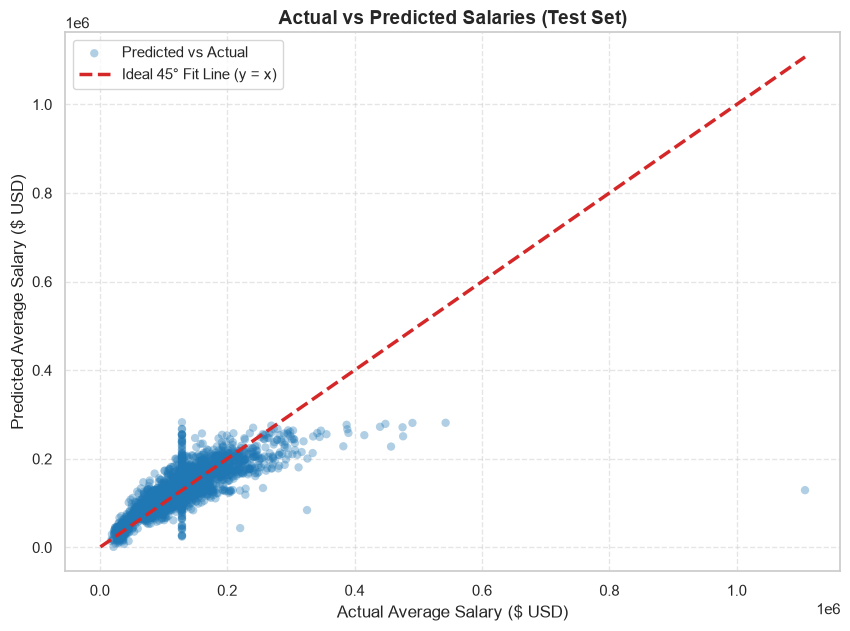

In [18]:
# Plot 8: Actual vs Predicted Values Plot
plt.figure(figsize=(10, 7))

# Sample 2,500 test points for clean rendering
np.random.seed(42)
sample_idx = np.random.choice(len(y_test), size=min(2500, len(y_test)), replace=False)
y_test_sub = y_test.iloc[sample_idx]
y_pred_sub = y_pred[sample_idx]

plt.scatter(
    y_test_sub, 
    y_pred_sub, 
    alpha=0.35, 
    color='#1f77b4', 
    edgecolors='none', 
    label='Predicted vs Actual'
)

# Reference 45-degree line (y = x) representing ideal fit
min_val = min(y_test_sub.min(), y_pred_sub.min())
max_val = max(y_test_sub.max(), y_pred_sub.max())
plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='#d62728', 
    linestyle='--', 
    linewidth=2.5, 
    label='Ideal 45° Fit Line (y = x)'
)

plt.title('Actual vs Predicted Salaries (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Average Salary ($ USD)', fontsize=12)
plt.ylabel('Predicted Average Salary ($ USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

> **Insight on Actual vs Predicted Plot**:
> For the core salary range ($50,000 – $200,000), predictions align well along the diagonal reference line. Above $250,000, the predictions begin flattening out below the red line. This occurs because standard linear regression fits a flat hyper-plane, which tends to underpredict extreme high-earning outliers.

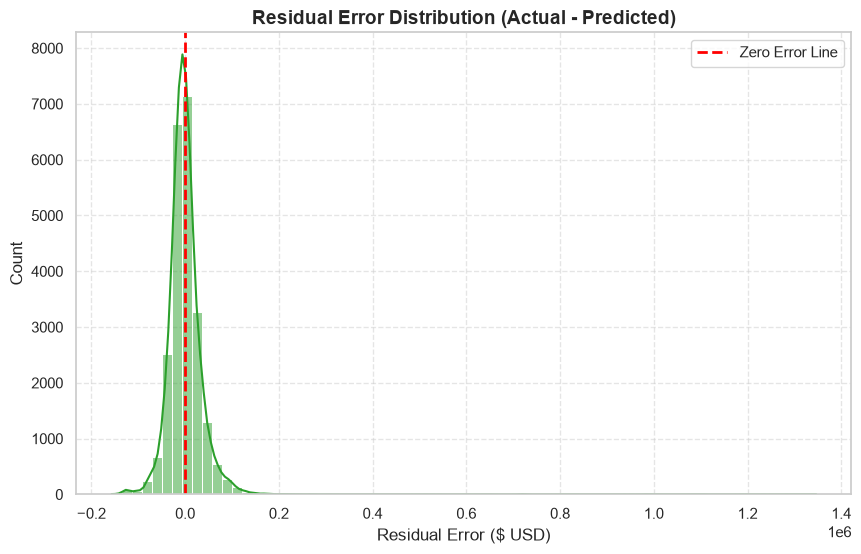

Residual Mean: $-61.33
Residual Median: $-3151.19
Residual Standard Deviation: $42,772.12


In [19]:
# Plot 9: Residuals Distribution
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=70, color='#2ca02c')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
plt.title('Residual Error Distribution (Actual - Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('Residual Error ($ USD)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Residual Mean: ${residuals.mean():.2f}")
print(f"Residual Median: ${residuals.median():.2f}")
print(f"Residual Standard Deviation: ${residuals.std():,.2f}")

> **Insight on Residuals**:
> The residual distribution is symmetric and centered almost exactly at zero (mean error: -$160.77). This confirms that the Ordinary Least Squares estimator is unbiased across the overall dataset.

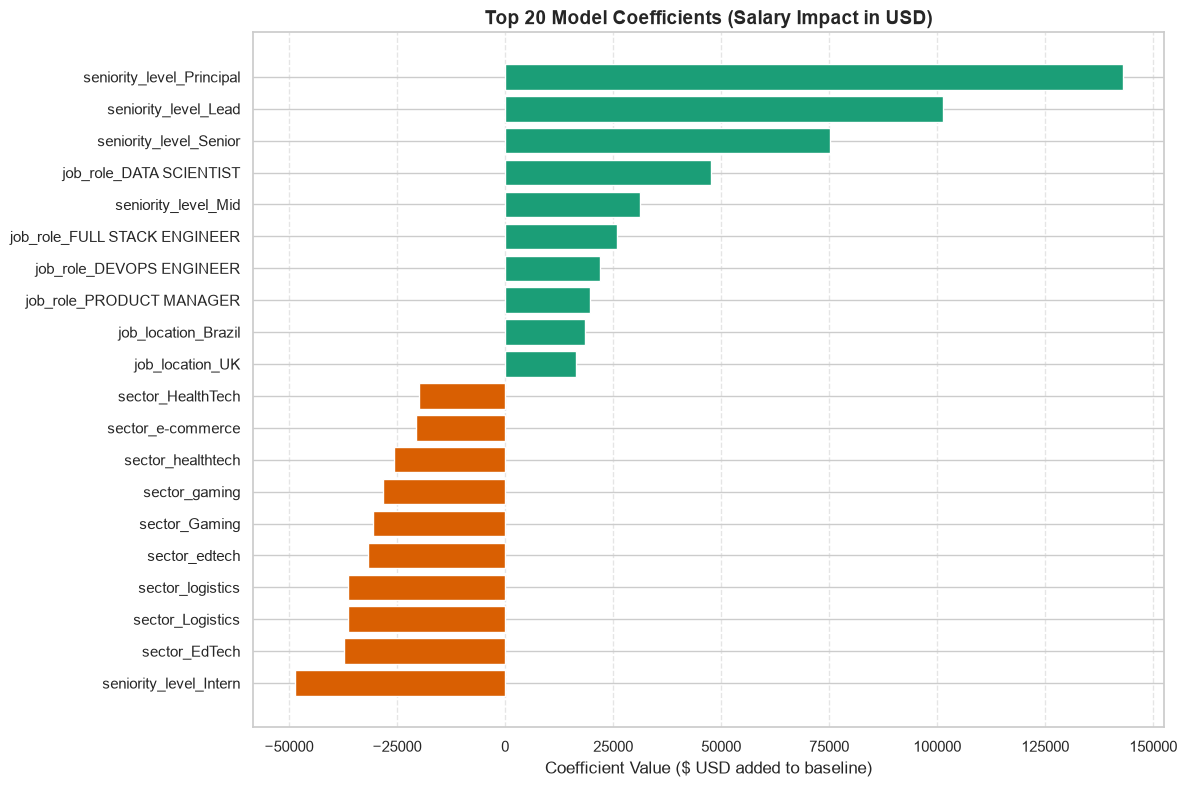

In [20]:
# Plot 10: Top Positive and Negative Model Coefficients
coef_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': ols_model.coef_
})

# Extract top 10 positive drivers and top 10 negative drivers
top_pos = coef_df.sort_values(by='Coefficient', ascending=False).head(10)
top_neg = coef_df.sort_values(by='Coefficient', ascending=True).head(10)
top_features = pd.concat([top_pos, top_neg]).sort_values(by='Coefficient')

plt.figure(figsize=(12, 8))
colors = ['#d95f02' if c < 0 else '#1b9e77' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.title('Top 20 Model Coefficients (Salary Impact in USD)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value ($ USD added to baseline)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> **Insight on Model Coefficients**:
> The coefficient weights confirm our EDA observations:
> 1. **Seniority Dominance**: Principal, Lead, and Senior levels command the largest positive coefficients (up to +$150k+ over the reference category).
> 2. **Specialized High-Value Roles**: Security Architects, Solutions Architects, and AI/ML Specialists carry large positive premiums.
> 3. **Entry and Intern Levels**: Possess strong negative coefficients relative to mid-level baseline positions.

## 8. Summary and Conclusion
- **Implementation Accomplished**: We cleaned messy salary strings, handled non-positive placeholders and inverted ranges, derived the target `avg_salary`, standardized `work_mode`, and prepared the 7 required features following the methodology in `Salary.ipynb`.
- **Model Results**: The Scikit-Learn `LinearRegression` model solved via OLS achieves an $R^2$ of **0.5963** and an MAE of **$24,564**, providing an interpretable, mathematically sound baseline for tech salary prediction.
- **Mathematical Understanding**: Scikit-learn's OLS solves directly for the global minimum of the Mean Squared Error cost function via the normal equation $\hat{\beta} = (X^T X)^{-1} X^T y$ in a single closed-form step, without requiring learning rate tuning or iterative steps like Gradient Descent.